## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
import duckdb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, train_repeated_cv, biomarker_summary_stats
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

✓ Imports successful
✓ Shared utilities loaded


## LOAD DATA

In [2]:
# Connect to HiRiD DuckDB
db_path = '/home/gaga/data/physionet/HiRiD/hirid.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to HiRiD database: {db_path}")

✓ Connected to HiRiD database: /home/gaga/data/physionet/HiRiD/hirid.duckdb


In [3]:
# Load patient cohort - patients with liver enzyme measurements
# Focus on patients with bilirubin or liver enzyme measurements

n_sample_patients = 20000

# Step 1: Get patient IDs with liver-related measurements
liver_query = f"""
SELECT DISTINCT CAST(o.patientid AS INTEGER) as patientid
FROM observations o
WHERE 
    (
        -- Bilirubin
        o.variableid = '20004300'
        -- AST
        OR o.variableid = '24000330'
        -- ALT
        OR o.variableid = '20002600'
        -- INR
        OR o.variableid = '24000567'
        -- Albumin
        OR o.variableid = '24000605'
    )
LIMIT {n_sample_patients}
"""

liver_patients = conn.execute(liver_query).fetchdf()['patientid'].tolist()
print(f"Step 1: Found {len(liver_patients):,} patients with liver measurements")

# Step 2: Get patient demographics
patient_query = f"""
SELECT 
    CAST(g.patientid AS INTEGER) as patientid,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time,
    g.sex,
    CAST(g.age AS INTEGER) as age,
    g.discharge_status,
    COUNT(DISTINCT o.datetime) as n_observations,
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 as los_days
FROM ref_general_table g
INNER JOIN observations o ON g.patientid = o.patientid
WHERE CAST(g.patientid AS INTEGER) IN {tuple(liver_patients)}
GROUP BY g.patientid, g.admissiontime, g.sex, g.age, g.discharge_status
HAVING 
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 >= 2.0
    AND COUNT(DISTINCT o.datetime) >= 100
"""

patient_df = conn.execute(patient_query).fetchdf()

print(f"\n✓ Loaded {len(patient_df):,} patients with liver measurements")
print(f"  Mean LOS: {patient_df['los_days'].mean():.1f} days")
print(f"  Mean age: {patient_df['age'].mean():.1f} years")

Step 1: Found 20,000 patients with liver measurements

✓ Loaded 6,072 patients with liver measurements
  Mean LOS: 6.2 days
  Mean age: 62.4 years


In [4]:
# Sample subset for analysis
n_patients = min(5000, len(patient_df))
patient_subset = patient_df.sample(n_patients, random_state=920)['patientid'].tolist()

print(f"✓ Using {len(patient_subset):,} patients for analysis")

✓ Using 5,000 patients for analysis


In [5]:
# Load bilirubin measurements (primary biomarker for liver failure)
# Bilirubin ID: 20004300 (µmol/L)
bilirubin_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    CAST(o.value AS DOUBLE) as bilirubin,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '20004300'
    AND o.value IS NOT NULL
    AND CAST(o.value AS DOUBLE) > 0
    AND CAST(o.value AS DOUBLE) < 800  -- Remove outliers (µmol/L)
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading bilirubin measurements...")
bilirubin_df = conn.execute(bilirubin_query).fetchdf()

print(f"\n✓ Loaded {len(bilirubin_df):,} bilirubin measurements")
print(f"  Patients with bilirubin: {bilirubin_df['patientid'].nunique():,}")
if len(bilirubin_df) > 0:
    print(f"  Mean bilirubin: {bilirubin_df['bilirubin'].mean():.1f} µmol/L")
    print(f"  Median bilirubin: {bilirubin_df['bilirubin'].median():.1f} µmol/L")

Loading bilirubin measurements...

✓ Loaded 34,315 bilirubin measurements
  Patients with bilirubin: 3,361
  Mean bilirubin: 39.4 µmol/L
  Median bilirubin: 14.0 µmol/L


In [6]:
# Load INR measurements
inr_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    CAST(o.value AS DOUBLE) as inr,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '24000567'
    AND o.value IS NOT NULL
    AND CAST(o.value AS DOUBLE) >= 0.5
    AND CAST(o.value AS DOUBLE) <= 15  -- Remove outliers
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading INR measurements...")
inr_df = conn.execute(inr_query).fetchdf()

print(f"\n✓ Loaded {len(inr_df):,} INR measurements")
print(f"  Patients with INR: {inr_df['patientid'].nunique():,}")
if len(inr_df) > 0:
    print(f"  Mean INR: {inr_df['inr'].mean():.2f}")
    print(f"  Median INR: {inr_df['inr'].median():.2f}")

Loading INR measurements...

✓ Loaded 37,139 INR measurements
  Patients with INR: 4,233
  Mean INR: 1.30
  Median INR: 1.14


In [7]:
# Load GCS for encephalopathy assessment
gcs_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.variableid,
    CAST(o.value AS DOUBLE) as value,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid IN ('10000100', '10000200', '10000300')  -- GCS eye, verbal, motor
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading GCS data...")
gcs_df = conn.execute(gcs_query).fetchdf()

print(f"\n✓ Loaded {len(gcs_df):,} GCS measurements")
print(f"  Patients with GCS: {gcs_df['patientid'].nunique():,}")

Loading GCS data...

✓ Loaded 751,506 GCS measurements
  Patients with GCS: 4,999


In [8]:
# Load vitals and labs - identify available variables from reference table
# Based on HiRiD variable reference, get IDs for key clinical variables

key_vars_query = """
SELECT DISTINCT
    CAST("ID" AS INTEGER) as variableid,
    "Variable Name" as variable_name,
    "Unit" as unit,
    "Source Table" as source_table
FROM ref_hirid_variable_reference
WHERE 
    -- Vitals
    "Variable Name" = 'Heart rate'
    OR "Variable Name" = 'Core body temperature'
    OR "Variable Name" = 'Invasive systolic arterial pressure'
    OR "Variable Name" = 'Invasive diastolic arterial pressure'
    OR "Variable Name" = 'Invasive mean arterial pressure'
    OR "Variable Name" = 'Non-invasive systolic arterial pressure'
    OR "Variable Name" = 'Non-invasive diastolic arterial pressure'
    OR "Variable Name" = 'Non-invasive mean arterial pressure'
    OR "Variable Name" = 'Respiratory rate'
    OR "Variable Name" = 'Peripheral oxygen saturation'
    -- Labs - Blood Chemistry
    OR "Variable Name" = 'Glucose [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Sodium [Moles/volume] in Blood'
    OR "Variable Name" = 'Potassium [Moles/volume] in Blood'
    OR "Variable Name" = 'Chloride [Moles/volume] in Blood'
    OR "Variable Name" = 'Bicarbonate [Moles/volume] in Arterial blood'
    OR "Variable Name" = 'Calcium.ionized [Moles/volume] in Blood'
    OR "Variable Name" = 'Magnesium [Moles/volume] in Blood'
    OR "Variable Name" = 'Phosphate [Moles/volume] in Blood'
    -- Labs - Renal
    OR "Variable Name" = 'Urea [Moles/volume] in Venous blood'
    OR "Variable Name" = 'Creatinine [Moles/volume] in Blood'
    -- Labs - Hematology
    OR "Variable Name" = 'Hemoglobin [Mass/volume] in Blood'
    OR "Variable Name" = 'Leukocytes [#/volume] in Blood'
    OR "Variable Name" = 'Platelets [#/volume] in Blood'
    -- Labs - Coagulation
    OR "Variable Name" = 'INR in Blood by Coagulation assay'
    OR "Variable Name" = 'aPTT in Blood by Coagulation assay'
    -- Labs - Liver/Metabolic
    OR "Variable Name" = 'Bilirubin.total [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Albumin [Mass/volume] in Serum or Plasma'
    -- Labs - Other
    OR "Variable Name" = 'Lactate [Mass/volume] in Arterial blood'
    -- Body measurements
    OR "Variable Name" = 'Body weight'
ORDER BY "Variable Name"
"""

key_vars = conn.execute(key_vars_query).fetchdf()
key_vars['unit'] = key_vars['unit'].fillna('N/A')
print(f"\n📊 Key clinical variables available in HiRiD:")
print(f"{'Variable ID':<12} {'Variable Name':<60} {'Unit':<15}")
print("="*100)
for _, row in key_vars.iterrows():
    print(f"{row['variableid']:<12} {row['variable_name']:<60} {row['unit']:<15}")

print(f"\n✓ Found {len(key_vars)} key clinical variables")

# Create variable ID to column name mapping (handle BP variants properly)
var_id_to_col = {}
for _, row in key_vars.iterrows():
    var_name = row['variable_name']
    var_id = str(row['variableid'])
    
    # Create concise column names, keeping BP types separate
    if 'Invasive systolic' in var_name:
        col_name = 'sbp_invasive'
    elif 'Invasive diastolic' in var_name:
        col_name = 'dbp_invasive'
    elif 'Invasive mean arterial' in var_name:
        col_name = 'mbp_invasive'
    elif 'Non-invasive systolic' in var_name:
        col_name = 'sbp_noninvasive'
    elif 'Non-invasive diastolic' in var_name:
        col_name = 'dbp_noninvasive'
    elif 'Non-invasive mean arterial' in var_name:
        col_name = 'mbp_noninvasive'
    elif 'Heart rate' in var_name:
        col_name = 'heart_rate'
    elif 'temperature' in var_name.lower():
        col_name = 'temperature'
    elif 'Respiratory rate' in var_name:
        col_name = 'respiratory_rate'
    elif 'oxygen saturation' in var_name.lower():
        col_name = 'spo2'
    elif 'Glucose' in var_name:
        col_name = 'glucose'
    elif 'Sodium' in var_name:
        col_name = 'sodium'
    elif 'Potassium' in var_name:
        col_name = 'potassium'
    elif 'Chloride' in var_name:
        col_name = 'chloride'
    elif 'Bicarbonate' in var_name:
        col_name = 'bicarbonate'
    elif 'Calcium' in var_name:
        col_name = 'calcium'
    elif 'Magnesium' in var_name:
        col_name = 'magnesium'
    elif 'Phosphate' in var_name:
        col_name = 'phosphate'
    elif 'Urea' in var_name:
        col_name = 'bun'
    elif 'Creatinine' in var_name:
        col_name = 'creatinine'
    elif 'Hemoglobin' in var_name:
        col_name = 'hemoglobin'
    elif 'Leukocytes' in var_name:
        col_name = 'wbc'
    elif 'Platelets' in var_name:
        col_name = 'platelets'
    elif 'INR' in var_name:
        col_name = 'inr'
    elif 'aPTT' in var_name:
        col_name = 'ptt'
    elif 'Bilirubin' in var_name:
        col_name = 'bilirubin'
    elif 'Albumin' in var_name:
        col_name = 'albumin'
    elif 'Lactate' in var_name:
        col_name = 'lactate'
    elif 'weight' in var_name.lower():
        col_name = 'weight'
    else:
        col_name = var_name.lower().replace(' ', '_')[:30]
    
    var_id_to_col[var_id] = col_name

print(f"\n📋 Variable mapping (ID → Column name):")
for var_id, col_name in sorted(var_id_to_col.items(), key=lambda x: x[1]):
    var_name = key_vars[key_vars['variableid'] == int(var_id)]['variable_name'].iloc[0]
    print(f"   {var_id:>10} → {col_name:25s} ({var_name})")

# Load observations for these variables from the patient subset
var_ids_str = "', '".join(var_id_to_col.keys())
obs_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.variableid,
    CAST(o.value AS DOUBLE) as value
FROM observations o
WHERE 
    o.variableid IN ('{var_ids_str}')
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print(f"\n⏳ Loading observations for {len(patient_subset):,} patients...")
obs_df = conn.execute(obs_query).fetchdf()

# Map variable IDs to column names
obs_df['variable'] = obs_df['variableid'].astype(str).map(var_id_to_col)

print(f"\n✓ Loaded {len(obs_df):,} observations")
print(f"  Unique patients: {obs_df['patientid'].nunique():,}")
print(f"  Unique variables: {obs_df['variable'].nunique()}")
print(f"  Time range: {obs_df['charttime'].min()} to {obs_df['charttime'].max()}")

# Show observation counts per variable
print(f"\n📊 Observations per variable:")
var_counts = obs_df.groupby('variable').size().sort_values(ascending=False)
for var_name, count in var_counts.items():
    print(f"   {var_name:25s}: {count:>10,} observations")


📊 Key clinical variables available in HiRiD:
Variable ID  Variable Name                                                Unit           
24000605     Albumin [Mass/volume] in Serum or Plasma                     g/L            
20004200     Bicarbonate [Moles/volume] in Arterial blood                 mmol/l         
20004300     Bilirubin.total [Moles/volume] in Serum or Plasma            umol/l         
10000400     Body weight                                                  kg             
24000522     Calcium.ionized [Moles/volume] in Blood                      mmol/l         
24000439     Chloride [Moles/volume] in Blood                             mmol/l         
24000521     Chloride [Moles/volume] in Blood                             mmol/l         
410          Core body temperature                                        °C             
20000600     Creatinine [Moles/volume] in Blood                           umol/l         
24000523     Glucose [Moles/volume] in Serum or Plasma

In [9]:
# convert creatinine in vitals_labs to mg/dl
obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] = obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] / 88.4

## PREPROCESS

In [10]:
# Calculate baseline bilirubin (first 24h)
bilirubin_df['charttime'] = pd.to_datetime(bilirubin_df['charttime'])
bilirubin_df['admission_time'] = pd.to_datetime(bilirubin_df['admission_time'])

first_24h = bilirubin_df[bilirubin_df['charttime'] <= bilirubin_df['admission_time'] + pd.Timedelta(hours=24)]

baseline_bili = first_24h.groupby('patientid')['bilirubin'].first().reset_index()
baseline_bili.columns = ['patientid', 'baseline_bilirubin']

print(f"\nBaseline Bilirubin:")
print(f"   Patients with baseline: {len(baseline_bili):,}")
print(f"   Mean: {baseline_bili['baseline_bilirubin'].mean():.1f} µmol/L")
print(f"   Median: {baseline_bili['baseline_bilirubin'].median():.1f} µmol/L")


Baseline Bilirubin:
   Patients with baseline: 2,363
   Mean: 27.7 µmol/L
   Median: 13.0 µmol/L


In [11]:
# Filter patients with sufficient measurements
bili_counts = bilirubin_df.groupby('patientid').size()
valid_patients = bili_counts[bili_counts >= 3].index

bilirubin_filtered = bilirubin_df[bilirubin_df['patientid'].isin(valid_patients)]
patient_final = patient_df[patient_df['patientid'].isin(valid_patients)].merge(
    baseline_bili, on='patientid', how='inner'
)

print(f"\nFiltering:")
print(f"   Patients with ≥3 bilirubin measurements: {len(patient_final):,}")


Filtering:
   Patients with ≥3 bilirubin measurements: 2,108


In [12]:
# Create time series
bili_ts = bilirubin_filtered.merge(
    patient_final[['patientid', 'baseline_bilirubin', 'admission_time']], 
    on=['patientid', 'admission_time'], 
    how='left'
)

bili_ts['time_days'] = (bili_ts['charttime'] - bili_ts['admission_time']).dt.total_seconds() / 86400
bili_ts['time_day'] = bili_ts['time_days'].astype(int)

# Rename for trajectory script
bili_ts = bili_ts.rename(columns={'bilirubin': 'lab_value'})
bili_ts = bili_ts.drop_duplicates(subset=['patientid', 'charttime'])

print(f"\n✓ Time series created")
print(f"   Total measurements: {len(bili_ts):,}")
print(f"   Time range: {bili_ts['time_days'].min():.1f} to {bili_ts['time_days'].max():.1f} days")


✓ Time series created
   Total measurements: 12,156
   Time range: -0.0 to 27.9 days


In [13]:
# Save bilirubin time series for trajectory computation
output_path = '../../results/hirid/liver/bilirubin_timeseries.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

bili_ts.to_csv(output_path, index=False)

print(f"\n✓ Saved bilirubin time series: {output_path}")
print(f"   Shape: {bili_ts.shape}")


✓ Saved bilirubin time series: ../../results/hirid/liver/bilirubin_timeseries.csv
   Shape: (12156, 7)


### AGGREGATE FEATURES

In [14]:
# Merge observations with patient admission times to calculate time_day
obs_df = obs_df.merge(
    patient_final[['patientid', 'admission_time']],
    on='patientid',
    how='inner'
)

obs_df['charttime'] = pd.to_datetime(obs_df['charttime'])
obs_df['admission_time'] = pd.to_datetime(obs_df['admission_time'])
obs_df['time_day'] = ((obs_df['charttime'] - obs_df['admission_time']).dt.total_seconds() / 86400).astype(int)

print(f"\n✓ Calculated time_day for observations")
print(f"  Time range: {obs_df['time_day'].min()} to {obs_df['time_day'].max()} days")

# Define valid ranges for each variable (clinically plausible values)
valid_ranges = {
    # Vitals
    'heart_rate': (20, 250),
    'temperature': (32, 42),
    'sbp_invasive': (40, 250),
    'dbp_invasive': (20, 180),
    'mbp_invasive': (30, 200),
    'sbp_noninvasive': (40, 250),
    'dbp_noninvasive': (20, 180),
    'mbp_noninvasive': (30, 200),
    'respiratory_rate': (4, 60),
    'spo2': (50, 100),
    
    # Labs - Chemistry
    'glucose': (20, 800),      # mg/dL (needs conversion from mmol/L)
    'sodium': (100, 180),      # mmol/L
    'potassium': (1.5, 10),    # mmol/L
    'chloride': (60, 140),     # mmol/L
    'bicarbonate': (5, 50),    # mmol/L
    'calcium': (0.5, 2.0),     # mmol/L (ionized)
    'magnesium': (0.3, 3.0),   # mmol/L
    'phosphate': (0.3, 4.0),   # mmol/L
    
    # Labs - Renal
    'bun': (0.5, 50),          # mmol/L (urea)
    'creatinine': (0.1, 15),  # mg/dL 
    
    # Labs - Hematology
    'hemoglobin': (40, 200),   # g/L
    'wbc': (0.1, 100),         # G/L (10^9/L)
    'platelets': (5, 1500),    # G/L (10^9/L)
    
    # Labs - Coagulation
    'inr': (0.5, 15),
    'ptt': (10, 300),          # seconds (aPTT)
    
    # Labs - Liver
    'bilirubin': (2, 800),     # µmol/L
    'albumin': (10, 60),       # g/L
    
    # Labs - Other
    'lactate': (0.2, 30),      # mmol/L
    'weight': (30, 300),       # kg
}

valid_ranges_df = pd.DataFrame.from_dict(valid_ranges, orient='index', columns=['min', 'max'])

print(f"\n📋 Defined valid ranges for {len(valid_ranges)} variables")

# Filter observations based on valid ranges
obs_df = obs_df.merge(
    valid_ranges_df.reset_index().rename(columns={'index': 'variable'}),
    on='variable',
    how='left'
)
obs_clean = obs_df[obs_df['value'].between(obs_df['min'], obs_df['max'])]

print(f"\n✓ Filtered observations")
print(f"  Before: {len(obs_df):,}")
print(f"  After:  {len(obs_clean):,}")
print(f"  Removed: {len(obs_df) - len(obs_clean):,} ({100*(len(obs_df)-len(obs_clean))/len(obs_df):.1f}%)")

# Aggregate vitals and labs by patient and time_day
# Calculate min, max, mean, std for each variable
print(f"\n⏳ Aggregating observations...")

vitals_labs_agg = obs_clean.pivot_table(
    index=['patientid', 'time_day'],
    columns='variable',
    values='value',
    aggfunc=['min', 'max', 'mean']
)

vitals_labs_agg.columns = [f"{var}_{stat}" for stat, var in vitals_labs_agg.columns]
# ffill imputation
vitals_labs_agg = vitals_labs_agg.sort_index().groupby(level=0).ffill()

vitals_labs_agg = vitals_labs_agg.reset_index()

print(f"\n✓ Aggregated vitals and labs")
print(f"  Shape: {vitals_labs_agg.shape}")
print(f"  Features: {vitals_labs_agg.shape[1] - 2 } (excluding patientid, time_day)")
print(f"  Unique patients: {vitals_labs_agg['patientid'].nunique():,}")
print(f"  Time windows: {len(vitals_labs_agg):,}")


# Drop features with >20% missing values after imputation
missing_pct = vitals_labs_agg.isna().mean()
cols_to_drop = (missing_pct[missing_pct > 0.2].index).tolist()

vitals_labs_clean = vitals_labs_agg.drop(columns=cols_to_drop)

print(f"\n✓ Dropped high-missingness columns (>20%)")
print(f"  Remaining features: {vitals_labs_clean.shape[1] - 2}")
print(f"  Dropped: {vitals_labs_agg.shape[1] - vitals_labs_clean.shape[1]} columns")

# Show which features were kept
feature_cols = [c for c in vitals_labs_clean.columns if c not in ['patientid', 'time_day']]
print(f"\n📊 Kept features ({len(feature_cols)}):")
for col in sorted(feature_cols):
    pct_missing = vitals_labs_clean[col].isna().mean()
    print(f"   {col:40s}: {pct_missing:3.2%} missing")


✓ Calculated time_day for observations
  Time range: 0 to 28 days

📋 Defined valid ranges for 29 variables

✓ Filtered observations
  Before: 77,531,121
  After:  67,046,844
  Removed: 10,484,277 (13.5%)

⏳ Aggregating observations...

✓ Aggregated vitals and labs
  Shape: (15388, 89)
  Features: 87 (excluding patientid, time_day)
  Unique patients: 2,108
  Time windows: 15,388

✓ Dropped high-missingness columns (>20%)
  Remaining features: 66
  Dropped: 21 columns

📊 Kept features (66):
   bicarbonate_max                         : 0.71% missing
   bicarbonate_mean                        : 0.71% missing
   bicarbonate_min                         : 0.71% missing
   bilirubin_max                           : 0.01% missing
   bilirubin_mean                          : 0.01% missing
   bilirubin_min                           : 0.01% missing
   bun_max                                 : 1.05% missing
   bun_mean                                : 1.05% missing
   bun_min                       

In [15]:
patient_final = patient_final.merge(
    vitals_labs_clean,
    on='patientid',
    how='left'
)

patient_final.to_csv('../../results/hirid/liver/patient_features.csv', index=False)

## TRAJECTORY MODELING

Run standalone script for SLURM:
```bash
python ../hirid_liver_trajs.py --window-days 5.0 --n-batches 10
```

In [16]:
# Load pre-computed trajectory probabilities
trajectory_probs_path = '../../results/hirid/liver/liver_trajectory_probs_bayes.csv'

if os.path.exists(trajectory_probs_path):
    trajectory_probs = pd.read_csv(trajectory_probs_path)
    print(f"✓ Loaded trajectory probabilities from: {trajectory_probs_path}")
    print(f"   Shape: {trajectory_probs.shape}")
else:
    print(f"⚠️ File not found: {trajectory_probs_path}")
    print("   Run: python ../hirid_liver_trajs.py")

✓ Loaded trajectory probabilities from: ../../results/hirid/liver/liver_trajectory_probs_bayes.csv
   Shape: (4071, 8)


In [17]:
bili_ts = bili_ts.rename(columns={'lab_value': 'bilirubin'})

(<Figure size 1400x500 with 2 Axes>,
 (<Axes: title={'center': 'Trajectory Type Distribution'}, ylabel='Number of Observations'>,
  <Axes: title={'center': 'Bilirubin by Trajectory Type'}, ylabel='Bilirubin Level'>))

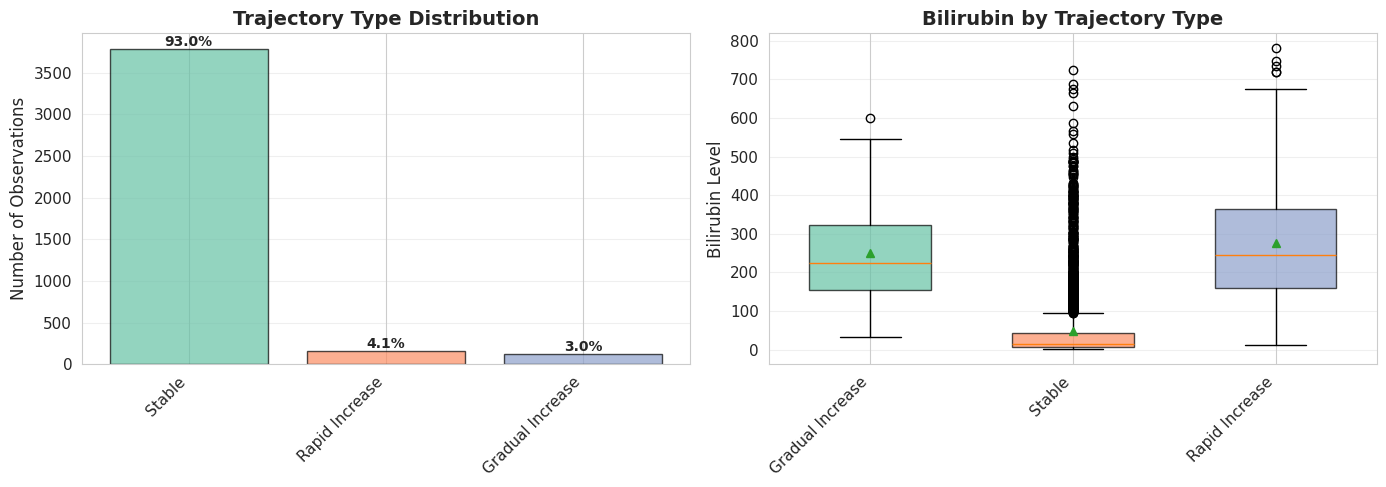

In [ ]:
# Visualize trajectory distribution
# Determine dominant trajectory
trajectory_probs['dominant_traj'] = trajectory_probs[[
    'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
]].idxmax(axis=1).str.replace('prob_', '')

# Merge with bilirubin data for visualization
traj_with_bili = trajectory_probs.merge(
    bili_ts[['patientid', 'time_day', 'bilirubin']],
    on=['patientid', 'time_day'],
    how='left'
)

plot_trajectory_distribution(traj_with_bili,
                              biomarker_col='bilirubin',
                              biomarker_name='Bilirubin')

## SUMMART STATISTICS

In [19]:
bili_ts = bili_ts.drop_duplicates(subset=['patientid', 'charttime'])

In [20]:
LOOKBACK_DAYS = 5
bili_summary_5d = biomarker_summary_stats(bili_ts, 'bilirubin', LOOKBACK_DAYS)

print(f"✓ Generated bilirubin summary stats: {len(bili_summary_5d):,} timepoints")
print(f"  Features: {list(bili_summary_5d.columns)}")
print(f"  Unique patients: {bili_summary_5d['patientid'].nunique():,}")

# Save summary stats
os.makedirs('../../results/hirid/liver', exist_ok=True)
bili_summary_5d.to_csv('../../results/hirid/liver/bilirubin_summary_5d.csv', index=False)
print(f"\n✓ Saved: results/hirid/liver/bilirubin_summary_5d.csv")

✓ Generated bilirubin summary stats: 11,108 timepoints
  Features: ['patientid', 'time_day', 'bilirubin_mean_5d', 'bilirubin_max_5d', 'bilirubin_min_5d', 'bilirubin_change_5d', 'bilirubin_linear_trend_5d', 'bilirubin_std_5d']
  Unique patients: 2,810

✓ Saved: results/hirid/liver/bilirubin_summary_5d.csv


## DEFINE OUTCOME

Acute liver failure defined as:
1. Bilirubin > 100 µmol/L (>6 mg/dL) AND
2. INR > 1.5 AND
3. Evidence of hepatic encephalopathy (GCS decline ≥ 2 points from baseline)

In [21]:
# Configuration
PREDICTION_GAP_DAYS = 1.0  # 24-hour gap
PREDICTION_WINDOW_DAYS = 5.0  # Predict liver failure within 5 days

print(f"📋 Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

# Prepare INR timing
inr_df['charttime'] = pd.to_datetime(inr_df['charttime'])
inr_df['admission_time'] = pd.to_datetime(inr_df['admission_time'])
inr_df['time_days'] = (inr_df['charttime'] - inr_df['admission_time']).dt.total_seconds() / 86400
inr_df['time_day'] = inr_df['time_days'].astype(int)

# Prepare GCS timing and calculate total GCS
gcs_df['charttime'] = pd.to_datetime(gcs_df['charttime'])
gcs_df['admission_time'] = pd.to_datetime(gcs_df['admission_time'])
gcs_df['time_days'] = (gcs_df['charttime'] - gcs_df['admission_time']).dt.total_seconds() / 86400
gcs_df['time_day'] = gcs_df['time_days'].astype(int)

# Pivot GCS components to get total score
gcs_pivot = gcs_df.pivot_table(
    index=['patientid', 'charttime', 'time_day'],
    columns='variableid',
    values='value',
    aggfunc='max'
).reset_index()

gcs_pivot.columns.name = None
gcs_pivot.columns = ['patientid', 'charttime', 'time_day', 'gcs_eye', 'gcs_motor', 'gcs_verbal']
gcs_pivot['gcs_total'] = gcs_pivot[['gcs_eye', 'gcs_motor', 'gcs_verbal']].sum(axis=1, min_count=3)

# Get baseline GCS
baseline_gcs = gcs_pivot[gcs_pivot['time_day'] <= 1].groupby('patientid')['gcs_total'].max().reset_index()
baseline_gcs.columns = ['patientid', 'baseline_gcs']

print(f"\n✓ Clinical data prepared")
print(f"  INR measurements: {len(inr_df):,}")
print(f"  GCS measurements: {len(gcs_pivot):,}")
print(f"  Baseline GCS available: {len(baseline_gcs):,}")

📋 Prediction Configuration:
   Gap:    1.0 days
   Window: 5.0 days
   Total:  6.0 days lookahead

✓ Clinical data prepared
  INR measurements: 37,139
  GCS measurements: 252,443
  Baseline GCS available: 4,991


In [22]:
patient_final['patientid'].nunique()

2108

In [23]:
# Define liver failure events
liver_failure_events = []
excluded_counts = {'already_failure': 0, 'no_future_data': 0}

for patientid, grp in patient_final.groupby('patientid'):
    grp = grp.sort_values('time_day')
    baseline = grp['baseline_bilirubin'].iloc[0] if 'baseline_bilirubin' in grp.columns else grp['bilirubin'].iloc[0]
    
    # Get baseline GCS for this patient
    patient_baseline_gcs = baseline_gcs[baseline_gcs['patientid'] == patientid]
    baseline_gcs_val = patient_baseline_gcs['baseline_gcs'].iloc[0] if len(patient_baseline_gcs) > 0 else 15
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_bili = grp.iloc[i]['bilirubin_mean']
        
        # Skip if already in failure (bili > 200)
        if current_bili > 200:
            excluded_counts['already_failure'] += 1
            continue
        
        # Define prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = bili_ts[(bili_ts['patientid'] == patientid) &
                                 (bili_ts['time_days'].between(prediction_start, prediction_end, inclusive='both'))]
        
        if len(future_window) == 0:
            excluded_counts['no_future_data'] += 1
            continue
        
        # Check for liver failure components
        # 1. High bilirubin (> 100 µmol/L)
        high_bili = (future_window['bilirubin'] > 100).any()
        failure_bili = (future_window['bilirubin'] > 200).any()
        
        # 2. High INR (> 1.5)
        inr_in_window = inr_df[
            (inr_df['patientid'] == patientid) &
            (inr_df['time_days'] >= prediction_start) &
            (inr_df['time_days'] <= prediction_end)
        ]
        high_inr = (inr_in_window['inr'] > 1.5).any() if len(inr_in_window) > 0 else False
        
        # 3. Encephalopathy (GCS decline ≥ 2)
        gcs_in_window = gcs_pivot[
            (gcs_pivot['patientid'] == patientid) &
            (gcs_pivot['time_day'] >= prediction_start) &
            (gcs_pivot['time_day'] <= prediction_end)
        ]
        
        if len(gcs_in_window) > 0:
            min_gcs = gcs_in_window['gcs_total'].min()
            gcs_decline = baseline_gcs_val - min_gcs
            encephalopathy = gcs_decline >= 2
        else:
            encephalopathy = False
        
        # Liver failure = all three criteria
        target_liver_failure = int((high_bili and high_inr and encephalopathy) or failure_bili)
        
        liver_failure_events.append({
            'patientid': patientid,
            'time_day': current_time,
            'target_liver_failure': target_liver_failure,
            'current_bilirubin': current_bili,
            'baseline_bilirubin': baseline,
            'bili_fold_change': current_bili / baseline if baseline > 0 else 1.0,
            'baseline_gcs': baseline_gcs_val,
            'prediction_gap_days': PREDICTION_GAP_DAYS,
            'prediction_window_days': PREDICTION_WINDOW_DAYS
        })

liver_outcomes_df = pd.DataFrame(liver_failure_events)

liver_outcomes_df = liver_outcomes_df.sort_values(['patientid', 'time_day'])
positive_first = liver_outcomes_df[liver_outcomes_df['target_liver_failure'] == 1].groupby('patientid').first().reset_index()
all_negatives = liver_outcomes_df[liver_outcomes_df['target_liver_failure'] == 0]
liver_outcomes_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['patientid', 'time_day']).reset_index(drop=True)

print(f"\n📊 Outcome Definition Summary:")
print(f"   Total prediction windows: {len(liver_outcomes_df):,}")
print(f"   Unique patients: {liver_outcomes_df['patientid'].nunique():,}")
print(f"   \n   Liver Failure Events:")
print(f"      Total events: {liver_outcomes_df['target_liver_failure'].sum():,}")
print(f"      Event rate: {100*liver_outcomes_df['target_liver_failure'].mean():.1f}%")


📊 Outcome Definition Summary:
   Total prediction windows: 6,756
   Unique patients: 1,408
   
   Liver Failure Events:
      Total events: 56
      Event rate: 0.8%


## CONSTRUCT PREDICTION DATASET

In [24]:
# Merge trajectory probabilities with outcomes
prediction_dataset = liver_outcomes_df.merge(
    trajectory_probs[[
        'patientid', 'time_day', 
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase'
    ]],
    on=['patientid', 'time_day'],
    how='left'
)

# Add derived trajectory feature
prediction_dataset['prob_worsening'] = (
    prediction_dataset['prob_gradual_increase'] + 
    prediction_dataset['prob_rapid_increase']
)

# add summary statistics
prediction_dataset = prediction_dataset.merge(bili_summary_5d.fillna(0),
                         on=['patientid', 'time_day'],
                         how='left')



# Merge patient demographics
patient_static = patient_final[['patientid', 'age', 'sex']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(
    patient_static,
    on='patientid',
    how='left'
)

# Define vitals/labs features list
vitals_labs_features = ['bicarbonate_min', 'bun_min',
       'calcium_min', 'chloride_min', 'creatinine_min', 'dbp_invasive_min',
       'heart_rate_min', 'hemoglobin_min', 'inr_min', 'lactate_min',
       'magnesium_min', 'mbp_invasive_min', 'phosphate_min', 'platelets_min',
       'potassium_min', 'respiratory_rate_min', 'sbp_invasive_min',
       'sodium_min', 'spo2_min', 'wbc_min', 'bicarbonate_max',
       'bun_max', 'calcium_max', 'chloride_max', 'creatinine_max',
       'dbp_invasive_max', 'heart_rate_max', 'hemoglobin_max', 'inr_max',
       'lactate_max', 'magnesium_max', 'mbp_invasive_max', 'phosphate_max',
       'platelets_max', 'potassium_max', 'respiratory_rate_max',
       'sbp_invasive_max', 'sodium_max', 'spo2_max', 'wbc_max',
       'bicarbonate_mean', 'bun_mean', 'calcium_mean', 'chloride_mean',
       'creatinine_mean', 'dbp_invasive_mean', 'heart_rate_mean',
       'hemoglobin_mean', 'inr_mean', 'lactate_mean', 'magnesium_mean',
       'mbp_invasive_mean', 'phosphate_mean', 'platelets_mean',
       'potassium_mean', 'respiratory_rate_mean', 'sbp_invasive_mean',
       'sodium_mean', 'spo2_mean', 'wbc_mean', 'weight_mean']

# Merge vitals and labs features
prediction_dataset = prediction_dataset.merge(
    patient_final[vitals_labs_features + ['patientid', 'time_day']].drop_duplicates(subset=['patientid', 'time_day']),
    on=['patientid', 'time_day'], 
    how='left'
)

# Backfill weight only
prediction_dataset['weight_mean'] = prediction_dataset.groupby('patientid')['weight_mean'].bfill()

# Add bilirubin-derived features
prediction_dataset['bili_elevated'] = (prediction_dataset['current_bilirubin'] > 50).astype(int)
prediction_dataset['bili_very_high'] = (prediction_dataset['current_bilirubin'] > 100).astype(int)

prediction_dataset = prediction_dataset.drop_duplicates(subset=['patientid', 'time_day'])



print(f"\n📋 Final Prediction Dataset:")
print(f"   Rows: {len(prediction_dataset):,}")
print(f"   Columns: {len(prediction_dataset.columns)}")
print(f"   Unique patients: {prediction_dataset['patientid'].nunique():,}")

# Save
os.makedirs('../../results/hirid/liver', exist_ok=True)
prediction_dataset.to_csv('../../results/hirid/liver/liver_prediction_dataset.csv', index=False)
print(f"\n✓ Saved: results/hirid/liver/liver_prediction_dataset.csv")


📋 Final Prediction Dataset:
   Rows: 6,756
   Columns: 84
   Unique patients: 1,408

✓ Saved: results/hirid/liver/liver_prediction_dataset.csv


In [25]:
prediction_dataset.columns

Index(['patientid', 'time_day', 'target_liver_failure', 'current_bilirubin',
       'baseline_bilirubin', 'bili_fold_change', 'baseline_gcs',
       'prediction_gap_days', 'prediction_window_days', 'prob_stable',
       'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
       'bilirubin_mean_5d', 'bilirubin_max_5d', 'bilirubin_min_5d',
       'bilirubin_change_5d', 'bilirubin_linear_trend_5d', 'bilirubin_std_5d',
       'age', 'sex', 'bicarbonate_min', 'bun_min', 'calcium_min',
       'chloride_min', 'creatinine_min', 'dbp_invasive_min', 'heart_rate_min',
       'hemoglobin_min', 'inr_min', 'lactate_min', 'magnesium_min',
       'mbp_invasive_min', 'phosphate_min', 'platelets_min', 'potassium_min',
       'respiratory_rate_min', 'sbp_invasive_min', 'sodium_min', 'spo2_min',
       'wbc_min', 'bicarbonate_max', 'bun_max', 'calcium_max', 'chloride_max',
       'creatinine_max', 'dbp_invasive_max', 'heart_rate_max',
       'hemoglobin_max', 'inr_max', 'lactate_max', 'magne

## FIT MODELS

In [26]:
# Define feature sets (updated to include summary stats and dynamic vitals/labs)
# Get summary stat column names if available
# Get summary stat column names
summary_stat_cols = [col for col in bili_summary_5d.columns if col not in ['patientid', 'time_day']]


feature_sets = {
    'Trajectory Only': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening'
    ],
    'Summary Stats Only': summary_stat_cols,
    'Trajectory + Summary Stats': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening'
    ] + summary_stat_cols,
    'Static Only': [
        'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_bilirubin', 'baseline_gcs', 'current_bilirubin', 'age', 'sex'
    ],
    'Trajectory + Static': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
        'baseline_bilirubin', 'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_gcs', 'current_bilirubin', 'age', 'sex'
    ],
    'Summary Stats + Static': summary_stat_cols + [
        'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_bilirubin', 'baseline_gcs', 'current_bilirubin', 'age', 'sex'
    ],
    'Trajectory + Summary Stats + Static': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening'
    ] + summary_stat_cols + [
        'baseline_bilirubin', 'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_gcs', 'current_bilirubin', 'age', 'sex'
    ],
    'Static + Dynamic': [
        'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_bilirubin', 'baseline_gcs', 'age', 'sex'
    ] + vitals_labs_features,
    'Trajectory + Static + Dynamic': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening',
        'baseline_bilirubin', 'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_gcs', 'age', 'sex'
    ] + vitals_labs_features,
    'Summary Stats + Static + Dynamic': summary_stat_cols + [
        'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_bilirubin', 'baseline_gcs', 'age', 'sex'
    ] + vitals_labs_features,
    'Trajectory + Summary Stats + Static + Dynamic': [
        'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening'
    ] + summary_stat_cols + [
        'baseline_bilirubin', 'bili_fold_change', 'bili_elevated', 'bili_very_high',
        'baseline_gcs', 'age', 'sex'
    ] + vitals_labs_features,
}

print(f"📋 Feature Set Summary:")
for name, features in feature_sets.items():
    print(f"   {name:35s}: {len(features):2d} features")

📋 Feature Set Summary:
   Trajectory Only                    :  4 features
   Summary Stats Only                 :  6 features
   Trajectory + Summary Stats         : 10 features
   Static Only                        :  8 features
   Trajectory + Static                : 12 features
   Summary Stats + Static             : 14 features
   Trajectory + Summary Stats + Static: 18 features
   Static + Dynamic                   : 68 features
   Trajectory + Static + Dynamic      : 72 features
   Summary Stats + Static + Dynamic   : 74 features
   Trajectory + Summary Stats + Static + Dynamic: 78 features


In [27]:
# Prepare data for modeling with improved imputation
prediction_clean = prediction_dataset.dropna(subset=['target_liver_failure'])

# Encode gender if present
if 'sex' in prediction_clean.columns:
    prediction_clean['sex'] = prediction_clean['sex'].map({'m': 1, 'f': 0, 'M': 1, 'F': 0})

print(f"\n🔧 Applying intelligent imputation strategy:")

# Trajectory probabilities
traj_cols = ['prob_stable', 'prob_gradual_increase', 'prob_rapid_increase', 'prob_worsening']
for col in traj_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby('patientid')[col].fillna(method='ffill', limit=2)
        prediction_clean[col] = prediction_clean[col].fillna(0)
print(f"   ✓ Trajectory probs: ffill limit=2, then 0")


# Current bilirubin
if 'current_bilirubin' in prediction_clean.columns:
    prediction_clean['current_bilirubin'] = prediction_clean.groupby('patientid')['current_bilirubin'].fillna(method='ffill', limit=2)
print(f"   ✓ Current bilirubin: ffill limit=2")

# Recalculate derived features
if 'current_bilirubin' in prediction_clean.columns:
    prediction_clean['bili_elevated'] = (prediction_clean['current_bilirubin'] > 50).fillna(0).astype(int)
    prediction_clean['bili_very_high'] = (prediction_clean['current_bilirubin'] > 100).fillna(0).astype(int)

# Targets and groups
y = prediction_clean['target_liver_failure']
groups = prediction_clean['patientid']

print(f"\n📋 Dataset for Modeling:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({y.mean():.1%})")
print(f"   Unique patients: {groups.nunique():,}")
print(f"   Avg windows/patient: {len(y) / groups.nunique():.1f}")
print(f"\n📊 Missingness after imputation:")
print(f"   Overall missing rate: {prediction_clean.drop(columns=['patientid', 'target_liver_failure']).isna().mean().mean():.2%}")


🔧 Applying intelligent imputation strategy:
   ✓ Trajectory probs: ffill limit=2, then 0
   ✓ Current bilirubin: ffill limit=2

📋 Dataset for Modeling:
   Total samples: 6,756
   Positive class: 56 (0.8%)
   Unique patients: 1,408
   Avg windows/patient: 4.8

📊 Missingness after imputation:
   Overall missing rate: 3.14%


## EVALUATE

In [28]:
# Repeated Cross-validation
n_repeats = 10
n_folds = 5
n_folds_total = n_repeats * n_folds

comparison_results = {}

print(f"\n🎯 Training models with {n_repeats}-Repeat {n_folds}-Fold CV:\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    fold_metrics = train_repeated_cv(
        prediction_df=prediction_clean,
        feature_cols=feature_cols,
        target_col='target_liver_failure',
        group_col='patientid',
        n_repeats=n_repeats,
        n_folds=n_folds,
        random_state=920
    )
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  AUROC:   {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  AUPR:    {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")


🎯 Training models with 10-Repeat 5-Fold CV:

Trajectory Only
------------------------------------------------------------
  AUROC:   0.532 ± 0.031
  AUPR:    0.009 ± 0.002

Summary Stats Only
------------------------------------------------------------
  AUROC:   0.876 ± 0.049
  AUPR:    0.177 ± 0.111

Trajectory + Summary Stats
------------------------------------------------------------
  AUROC:   0.866 ± 0.055
  AUPR:    0.189 ± 0.110

Static Only
------------------------------------------------------------
  AUROC:   0.922 ± 0.036
  AUPR:    0.147 ± 0.073

Trajectory + Static
------------------------------------------------------------
  AUROC:   0.910 ± 0.033
  AUPR:    0.160 ± 0.086

Summary Stats + Static
------------------------------------------------------------
  AUROC:   0.915 ± 0.043
  AUPR:    0.167 ± 0.092

Trajectory + Summary Stats + Static
------------------------------------------------------------
  AUROC:   0.917 ± 0.036
  AUPR:    0.174 ± 0.101

Static + Dynamic



📊 Performance Summary:
                                        Model         AUROC          AUPR
                              Trajectory Only 0.532 ± 0.031 0.009 ± 0.002
                           Summary Stats Only 0.876 ± 0.049 0.177 ± 0.111
                   Trajectory + Summary Stats 0.866 ± 0.055 0.189 ± 0.110
                                  Static Only 0.922 ± 0.036 0.147 ± 0.073
                          Trajectory + Static 0.910 ± 0.033 0.160 ± 0.086
                       Summary Stats + Static 0.915 ± 0.043 0.167 ± 0.092
          Trajectory + Summary Stats + Static 0.917 ± 0.036 0.174 ± 0.101
                             Static + Dynamic 0.948 ± 0.031 0.270 ± 0.092
                Trajectory + Static + Dynamic 0.947 ± 0.030 0.264 ± 0.084
             Summary Stats + Static + Dynamic 0.939 ± 0.047 0.290 ± 0.100
Trajectory + Summary Stats + Static + Dynamic 0.940 ± 0.047 0.322 ± 0.134

✓ Saved: results/hirid/liver/model_comparison_curves.png


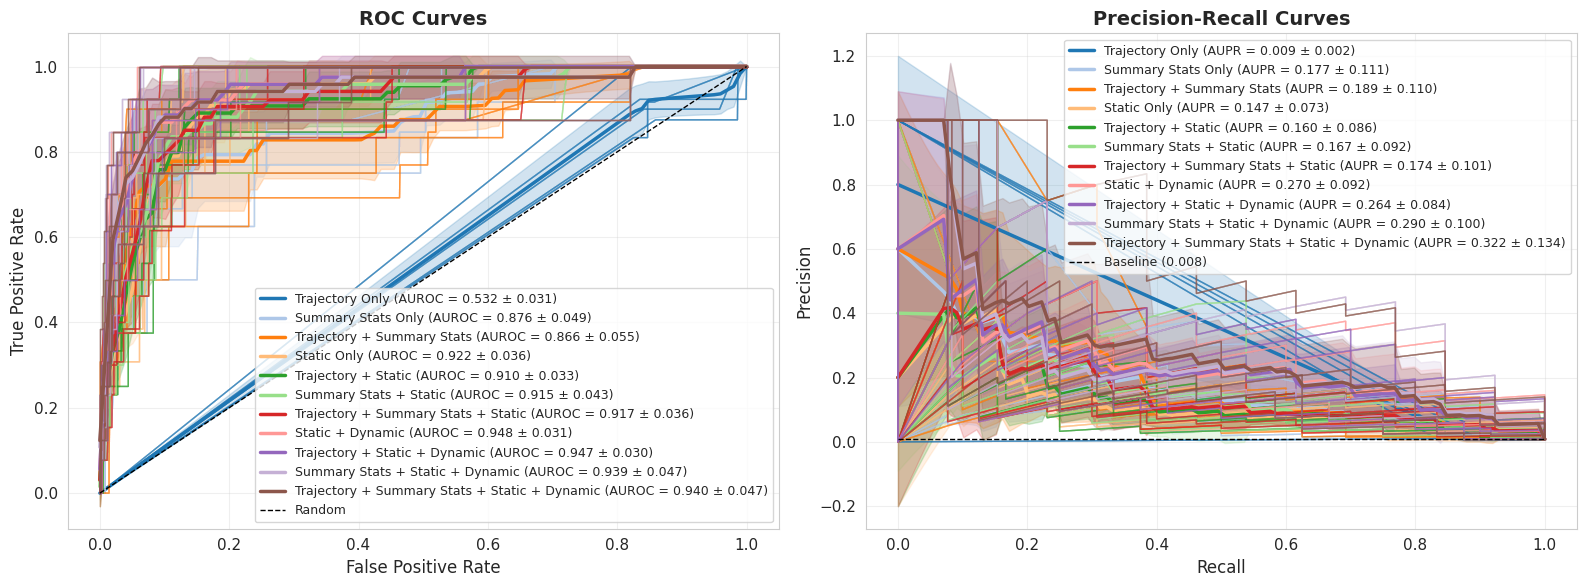

In [29]:
# Performance comparison
summary_df = pd.DataFrame([
    {
        'Model': name,
        'AUROC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\n📊 Performance Summary:")
print(summary_df.to_string(index=False))

# ROC & PR Curves
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_liver_failure',
    color_scheme='tab20'
)
plt.savefig('../../results/hirid/liver/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/liver/model_comparison_curves.png")
plt.show()


✓ Saved: results/hirid/liver/model_comparison_boxplots.png


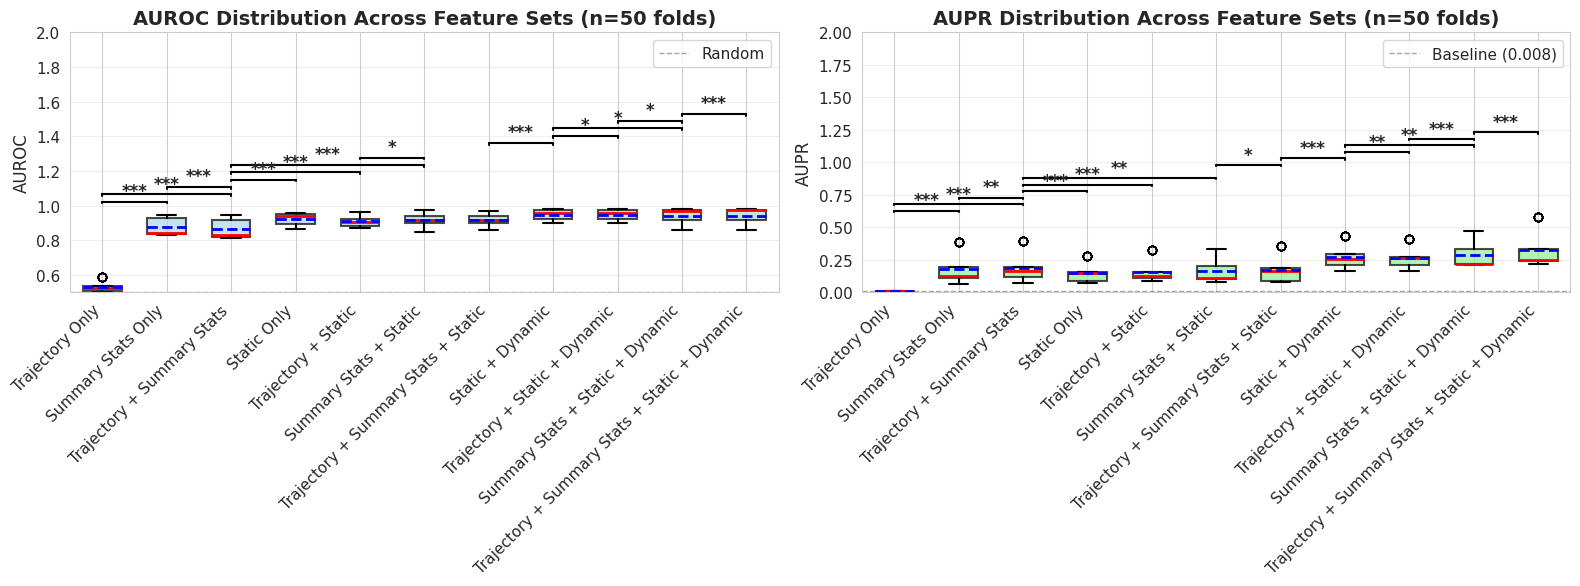


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Summary Stats Only                        0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.3437        +0.1677
Trajectory Only vs Trajectory + Summary Stats                0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.3337        +0.1795
Summary Stats Only vs Trajectory + Summary Stats             0.0000       ***   0.0061       **   
  Effect size (Δ):                                           -0.0099        +0.0118
Trajectory + Summary Stats vs Static Only                    0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.0560        -0.0414
Trajectory + Summary Stats

In [30]:
# Statistical significance testing
pairs_to_compare = [
    (0, 1),  # Trajectory vs Summary
    (0, 2),  # Trajectory vs Trajectory + Summary
    (1, 2),  # Summary vs Trajectory + Summary
    (2, 3),  # Trajectory + Summary vs Static Only
    (2, 4),  # Trajectory + Summary vs Trajectory + Static
    (2, 5),  # Trajectory + Summary vs Summary + Static
    (4, 5),  # Trajectory + Static vs Summary + Static

    (5, 6),  # Summary + Static vs Trajectory + Summary + Static
    (6, 7),  # Trajectory + Summary + Static vs Static + Dynamic
    (7, 8),  # Static + Dynamic vs Trajectory + Static + Dynamic
    (7, 9),  # Static + Dynamic vs Summary + Static + Dynamic
    (8, 9),  # Trajectory + Static + Dynamic vs Summary + Static + Dynamic
    (9, 10), # Summary + Static + Dynamic vs Trajectory + Summary + Static + Dynamic
    ]

fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_liver_failure',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total,
    roc_ylim=(0.5, 2),
    ap_ylim=(0, 2)
)
plt.savefig('../../results/hirid/liver/model_comparison_boxplots.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/liver/model_comparison_boxplots.png")
plt.show()

print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)